# Curved edges between neurons in the same layer

This focused example exercises `plot_paths()` in continuous-flow mode. Edges between distinct neurons with the same horizontal position are curved by default, while edges between different layers stay straight. Set `same_layer_edge_curvature=0` to recover the previous rendering.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "connectome_interpreter").is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from connectome_interpreter.utils import plot_paths

In [2]:
paths = pd.DataFrame(
    {
        "pre": ["source", "source", "A", "B", "A", "C", "middle"],
        "post": ["A", "B", "B", "C", "middle", "target", "target"],
        "weight": [0.8, 0.6, 0.7, 0.5, 0.4, 0.7, 0.9],
        "pre_layer": [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 2.0],
        "post_layer": [1.0, 1.0, 1.0, 1.0, 2.0, 3.0, 3.0],
    }
)
paths

,pre,post,weight,pre_layer,post_layer
0,source,A,0.8,0.0,1.0
1,source,B,0.6,0.0,1.0
2,A,B,0.7,1.0,1.0
3,B,C,0.5,1.0,1.0
4,A,middle,0.4,1.0,2.0
5,C,target,0.7,1.0,3.0
6,middle,target,0.9,2.0,3.0


## New default

The `A → B` and `B → C` arrows share a layer and therefore use curved paths.

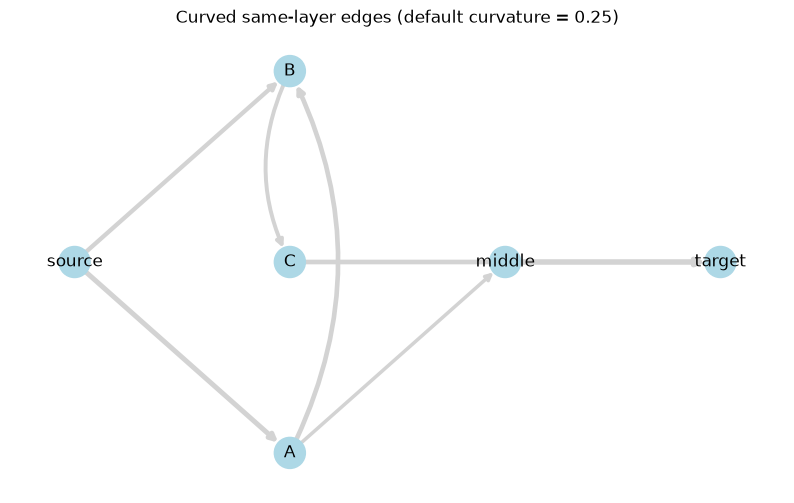

In [3]:
fig, ax = plot_paths(
    paths,
    figsize=(10, 6),
    edge_text=False,
    edge_width_scale=4,
    seed=0,
    show=False,
)
ax.set_title("Curved same-layer edges (default curvature = 0.25)")
plt.show()

## Backward-compatible opt-out

A curvature of zero reproduces the earlier straight vertical arrows.

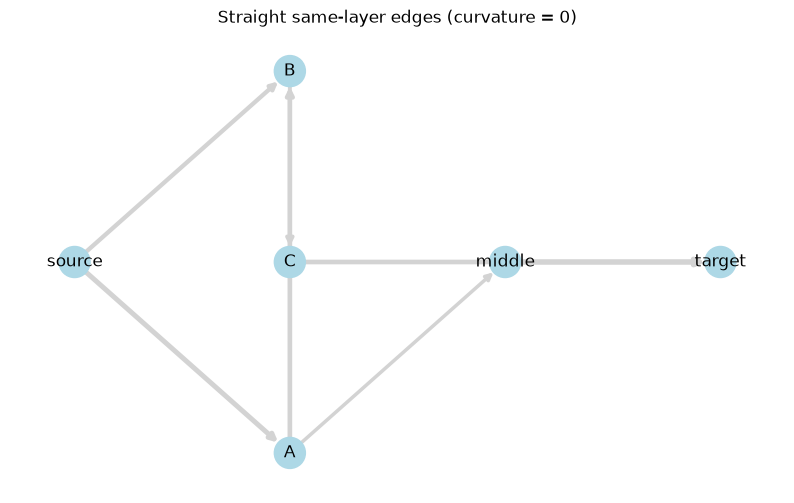

In [4]:
fig, ax = plot_paths(
    paths,
    figsize=(10, 6),
    edge_text=False,
    edge_width_scale=4,
    same_layer_edge_curvature=0,
    seed=0,
    show=False,
)
ax.set_title("Straight same-layer edges (curvature = 0)")
plt.show()